# ERCOT Load Forecasting

## 01 — Data Exploration

Goal: explore historical ERCOT electricity-demand data and understand its structure before building forecasting models.

## 1. Where the data comes from

ERCOT (Electric Reliability Council of Texas) operates the power grid for about 90% of Texas.
They publish historical hourly demand data for free on their website (no account or API key needed):

https://www.ercot.com/gridinfo/load/load_hist

The dataset is called **"Native Load"** and comes as one zip file per year, each containing a
single Excel file. Every row is one hour, and the columns are:

- `Hour Ending` — the timestamp for the hour (ERCOT reports load for the hour *ending* at this time)
- 8 columns with the load of each ERCOT **weather zone** (COAST, EAST, FWEST, NORTH, NCENT, SOUTH, SCENT, WEST)
- `ERCOT` — the total system load, which is just the sum of the zones

Load is measured in **megawatts (MW)**, i.e. the average power demand during that hour.

For forecasting we mainly need two columns: `Hour Ending` (the timestamp) and `ERCOT` (the total load).
We download four full years (2022–2025) so we can later look at daily, weekly, and yearly patterns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Download the raw data

The cell below downloads each year's zip file into `data/raw/`, extracts the Excel file,
and deletes the zip. If a year's Excel file is already there, it skips the download, so
re-running the notebook doesn't hit ERCOT's servers again.

We only use the standard library (`os`, `zipfile`) plus `requests` for the HTTP download.

In [ ]:
import os
import requests
import zipfile

#DOWNLOAD THE RAW EXCEL FILES FROM ERCOT'S PUBLIC "NATIVE LOAD" ARCHIVE INTO data/raw/
#(NOT TRACKED IN GIT - THIS CELL RECREATES THEM AND SKIPS YEARS ALREADY ON DISK)

# ERCOT posts one zip per year; the date in the URL is just when they created the page,
# so it is different for every year
data_urls = {
    2022: "https://www.ercot.com/files/docs/2022/02/08/Native_Load_2022.zip",
    2023: "https://www.ercot.com/files/docs/2023/02/09/Native_Load_2023.zip",
    2024: "https://www.ercot.com/files/docs/2024/02/06/Native_Load_2024.zip",
    2025: "https://www.ercot.com/files/docs/2025/02/11/Native_Load_2025.zip",
}

data_dir = "../data/raw"
os.makedirs(data_dir, exist_ok=True)

for year, url in data_urls.items():
    xlsx_path = os.path.join(data_dir, f"Native_Load_{year}.xlsx")
    if os.path.exists(xlsx_path):
        print(f"{year}: already downloaded, skipping")
        continue

    print(f"{year}: downloading...")
    response = requests.get(url, timeout=60)

    # save the zip, extract the Excel file inside it, then delete the zip
    zip_path = os.path.join(data_dir, f"Native_Load_{year}.zip")
    with open(zip_path, "wb") as f:
        f.write(response.content)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(data_dir)
    os.remove(zip_path)

print("done")

## 3. Load the data into pandas

`pd.read_excel()` reads an Excel file into a DataFrame. We read the four yearly files separately and then stack them on top of
each other with `pd.concat()`, which works because they all have exactly the same columns.

`ignore_index=True` renumbers the rows 0, 1, 2, ... in the combined DataFrame — otherwise each
year would keep its own row numbers and we would have four rows labelled 0, four labelled 1, etc.

In [4]:
# read each yearly Excel file and stack them into one DataFrame
yearly_dfs = []
for year in data_urls:
    xlsx_path = os.path.join(data_dir, f"Native_Load_{year}.xlsx")
    df_year = pd.read_excel(xlsx_path)
    print(year, df_year.shape)
    yearly_dfs.append(df_year)

df = pd.concat(yearly_dfs, ignore_index=True)
print("combined:", df.shape)

2022 (8760, 10)
2023 (8760, 10)
2024 (8784, 10)
2025 (8760, 10)
combined: (35064, 10)


2023 (8760, 10)


2024 (8784, 10)


2025 (8760, 10)
combined: (35064, 10)


In [37]:
# first look at the combined data

df.head()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,01/01/2022 01:00,12054.939199,1302.296674,4161.193625,757.843076,9676.300802,3172.878316,5908.031505,973.455700,38006.938896
1,01/01/2022 02:00,11793.290315,1259.355201,4147.907009,737.236591,9307.126712,3123.318608,5708.512022,959.775908,37036.522365
2,01/01/2022 03:00,11460.841252,1210.287905,4156.412366,725.610502,8920.424552,3003.396233,5463.522829,941.112359,35881.607998
3,01/01/2022 04:00,11244.980243,1179.311517,4149.811722,717.420214,8678.807826,2898.097471,5255.252404,920.373708,35044.055105
4,01/01/2022 05:00,11073.085585,1171.841803,4140.619028,719.178247,8573.370608,2825.100402,5164.172158,918.203309,34585.571140


In [38]:
df.describe()

,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,14002.758879,1765.123577,6126.175732,1373.626287,14829.075483,4148.298465,8443.381348,1335.256708,52023.696478
std,3061.132285,433.834442,1083.890513,361.999528,3998.398803,928.418536,2127.590922,261.945767,11022.217921
min,7128.496204,992.486128,3750.414759,681.366442,8189.853000,2301.030847,4743.243244,735.793806,31796.353940
25%,11712.762656,1451.551364,5224.779760,1087.435068,11965.962832,3415.034310,6844.850851,1142.287986,43867.690418
50%,13261.716479,1653.979047,6145.783298,1323.288607,13742.383459,3981.691464,7897.904218,1269.047321,49376.635797
75%,15810.666844,2005.941518,7016.133626,1609.861874,16921.602870,4781.218371,9658.659469,1475.304011,58263.044742
max,23963.415268,3696.721811,8773.080101,2732.085977,28312.541008,7155.621786,15664.703570,2230.497660,85464.116394


In [5]:
print(df.columns)
print(df[["WEST","EAST","NORTH"]].describe())

Index(['Hour Ending', 'COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH',
       'SCENT', 'WEST', 'ERCOT'],
      dtype='str')
               WEST          EAST         NORTH
count  35064.000000  35064.000000  35064.000000
mean    1335.256708   1765.123577   1373.626287
std      261.945767    433.834442    361.999528
min      735.793806    992.486128    681.366442
25%     1142.287986   1451.551364   1087.435068
50%     1269.047321   1653.979047   1323.288607
75%     1475.304011   2005.941518   1609.861874
max     2230.497660   3696.721811   2732.085977


In [39]:
print("Number of missing data in each column")
df.isna().sum()

Number of missing data in each column


Hour Ending    0
COAST          0
EAST           0
FWEST          0
NORTH          0
NCENT          0
SOUTH          0
SCENT          0
WEST           0
ERCOT          0
dtype: int64

In [6]:
zone_columns = [
    "COAST", "EAST", "FWEST", "NORTH",
    "NCENT", "SOUTH", "SCENT", "WEST"
]

df["zone_sum"] = df[zone_columns].sum(axis=1)

df["difference"] = df["ERCOT"] - df["zone_sum"]
df["difference"].describe()

 

count    3.506400e+04
mean     7.797175e-08
std      8.142141e-07
min     -3.000008e-06
25%     -7.275958e-12
50%      0.000000e+00
75%      9.999931e-07
max      3.000008e-06
Name: difference, dtype: float64

In [43]:
df.duplicated().sum()
df.shape

(35064, 12)

In [44]:
df["Hour Ending"].head(10)

0    01/01/2022 01:00
1    01/01/2022 02:00
2    01/01/2022 03:00
3    01/01/2022 04:00
4    01/01/2022 05:00
5    01/01/2022 06:00
6    01/01/2022 07:00
7    01/01/2022 08:00
8    01/01/2022 09:00
9    01/01/2022 10:00
Name: Hour Ending, dtype: object

In [45]:
df["Hour Ending"].tail(10)

35054    12/31/2025 15:00
35055    12/31/2025 16:00
35056    12/31/2025 17:00
35057    12/31/2025 18:00
35058    12/31/2025 19:00
35059    12/31/2025 20:00
35060    12/31/2025 21:00
35061    12/31/2025 22:00
35062    12/31/2025 23:00
35063    12/31/2025 24:00
Name: Hour Ending, dtype: object

In [7]:
print(type(df["Hour Ending"]))
print(type(df[["Hour Ending"]]))

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


In [8]:
has_24 = df["Hour Ending"].str.contains("24:00")

has_24.sum()

1461

In [9]:
df["Hour Ending"].map(type).value_counts()

Hour Ending
<class 'str'>                  35063
<class 'datetime.datetime'>        1
Name: count, dtype: int64

In [10]:
is_datetime = df["Hour Ending"].map(type) != str

df[is_datetime]

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,zone_sum,difference
8016,2022-12-01 01:00:00,9825.176507,1700.489394,5170.774232,1135.236419,13318.321331,2854.455756,7045.815981,1263.720051,42313.98967,42313.989671,-9.999931e-07


In [11]:
df.loc[is_datetime, "Hour Ending"]

8016    2022-12-01 01:00:00
Name: Hour Ending, dtype: object

In [12]:
df["Hour Ending"] = df["Hour Ending"].astype(str)   #CONVERTS EVERY VALUE IN "Hour Ending" TO STRING
df["Hour Ending"].map(type).value_counts()

Hour Ending
<class 'str'>    35064
Name: count, dtype: int64

### Daylight-Saving Time

ERCOT timestamps use local clock time. During the spring DST transition, one hour is skipped, while during the fall transition one hour is repeated and marked with `DST`.

Therefore, the `Hour Ending` column requires special handling before conversion to a standard datetime representation.

In [13]:
mask = df["Hour Ending"].str.contains("03/13/2022", na=False)
df[mask]

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,zone_sum,difference
1704,03/13/2022 01:00,11907.085970,1678.838686,4550.443583,999.284080,12571.416257,3735.234764,7379.604834,1236.595527,44058.503701,44058.503701,7.275958e-12
1705,03/13/2022 02:00,11830.051429,1680.793397,4545.274984,997.987976,12490.749674,3737.413927,7440.536381,1257.761646,43980.569414,43980.569414,0.000000e+00
1706,03/13/2022 04:00,11850.607625,1711.645009,4556.660404,1007.679962,12608.268793,3773.345604,7577.091137,1287.383510,44372.682044,44372.682044,0.000000e+00
1707,03/13/2022 05:00,12004.418768,1752.073151,4593.422300,1025.836266,12881.368203,3763.301584,7783.918641,1301.017847,45105.356759,45105.356760,-1.000000e-06
1708,03/13/2022 06:00,12200.215435,1798.416766,4617.118419,1042.382580,13246.932194,3831.295762,8072.915407,1341.269477,46150.546040,46150.546040,-7.275958e-12
1709,03/13/2022 07:00,12487.715001,1859.027766,4604.538599,1076.962900,13720.549844,3952.753363,8436.492549,1402.545600,47540.585621,47540.585622,-1.000000e-06
1710,03/13/2022 08:00,12818.878960,1980.504010,4621.950816,1119.199625,14319.422880,4077.750010,8847.180973,1455.820744,49240.708018,49240.708018,-7.275958e-12
1711,03/13/2022 09:00,12818.584252,1968.731728,4602.070170,1127.805301,14450.360876,4070.195646,8905.416558,1451.968787,49395.133319,49395.133318,1.000000e-06
1712,03/13/2022 10:00,12545.854465,1853.941607,4542.652476,1097.291514,14010.375976,3873.597623,8383.413723,1382.171433,47689.298817,47689.298817,0.000000e+00
1713,03/13/2022 11:00,12256.344247,1712.802596,4497.615261,1049.745162,13464.890579,3562.588236,7754.899443,1289.982658,45588.868183,45588.868182,9.999931e-07


In [14]:
mask = df["Hour Ending"].str.contains("11/06/2022", na=False)
df[mask]
 

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,zone_sum,difference
7415,11/06/2022 01:00,9813.189015,1155.301835,5091.575690,782.340406,9439.023411,3072.821271,5523.387156,973.393076,35851.031860,35851.031860,7.275958e-12
7416,11/06/2022 02:00,9505.269578,1136.910380,5072.251182,763.259274,9051.816029,2942.822508,5288.456113,946.090399,34706.875462,34706.875463,-9.999931e-07
7417,11/06/2022 02:00 DST,9331.958672,1104.183137,5094.569030,752.622044,8844.275206,2888.351883,5113.815243,938.180082,34067.955296,34067.955297,-1.000000e-06
7418,11/06/2022 03:00,9295.908865,1108.619657,5059.677106,748.632124,8810.905628,2826.857791,5031.559822,929.756082,33811.917074,33811.917075,-1.000000e-06
7419,11/06/2022 04:00,9213.569518,1062.108320,5066.196633,741.241382,8707.610217,2788.070858,4995.137933,921.440070,33495.374930,33495.374931,-9.999931e-07
7420,11/06/2022 05:00,9256.410237,1091.464389,5022.325513,746.297178,8772.321605,2758.495659,4992.528485,925.071456,33564.914521,33564.914522,-1.000000e-06
7421,11/06/2022 06:00,9447.422606,1128.246189,5058.720308,763.837704,9061.596098,2722.761187,5066.201062,944.218539,34193.003694,34193.003693,1.000000e-06
7422,11/06/2022 07:00,9653.142792,1145.339697,5108.306323,792.930699,9448.379096,2765.501744,5270.047305,972.414291,35156.061947,35156.061947,0.000000e+00
7423,11/06/2022 08:00,9971.346294,1178.324360,5146.652050,815.303467,9913.972162,2848.664309,5530.103593,999.726975,36404.093208,36404.093210,-2.000001e-06
7424,11/06/2022 09:00,10490.817354,1254.258111,5183.583097,835.274644,10436.454673,3070.084741,5865.535817,1021.105665,38157.114101,38157.114102,-1.000000e-06


In [15]:
df["is_dst"] = df["Hour Ending"].str.contains("DST", na=False)   #GET THE APPROPRIATE ROWS OF COLUMNS

In [16]:
df["is_dst"].value_counts()

is_dst
False    35060
True         4
Name: count, dtype: int64

In [17]:
df.loc[df["is_dst"],["Hour Ending", "ERCOT"]]

,Hour Ending,ERCOT
7417,11/06/2022 02:00 DST,34067.955296
16153,11/05/2023 02:00 DST,35937.478720
24889,11/03/2024 02:00 DST,44626.241884
33625,11/02/2025 02:00 DST,39670.106541


In [18]:
is_24 = df["Hour Ending"].str.contains("24:00", na=False)

is_24.sum()

np.int64(1461)

In [19]:
df.loc[is_24, "Hour Ending"].head()

23     01/01/2022 24:00
47     01/02/2022 24:00
71     01/03/2022 24:00
95     01/04/2022 24:00
119    01/05/2022 24:00
Name: Hour Ending, dtype: str

In [20]:
df.loc[is_24, "Hour Ending"].tail()

34967    12/27/2025 24:00
34991    12/28/2025 24:00
35015    12/29/2025 24:00
35039    12/30/2025 24:00
35063    12/31/2025 24:00
Name: Hour Ending, dtype: str

In [42]:
time_clean = df["Hour Ending"].str.replace("DST", "", regex=False)
time_clean = time_clean.str.replace("24:00", "00:00", regex=False)

In [43]:
timestamp = pd.to_datetime(time_clean, format="mixed")
timestamp.loc[is_24] = timestamp.loc[is_24] + pd.Timedelta(days=1)

In [44]:
df["timestamp"] = timestamp  #FINALLY SAVE IT

df["timestamp"].duplicated().sum()

np.int64(4)

In [45]:
df.tail()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,zone_sum,difference,is_dst,timestamp
35059,12/31/2025 20:00,12400.963382,1727.552125,7809.048752,1695.381416,13247.718927,3896.191878,7725.023700,1366.821485,49868.701664,49868.701665,-9.999931e-07,False,2025-12-31 20:00:00
35060,12/31/2025 21:00,12179.429071,1730.405940,7914.007494,1680.087796,12946.659518,3743.168715,7514.969312,1361.081598,49069.809445,49069.809444,1.000000e-06,False,2025-12-31 21:00:00
35061,12/31/2025 22:00,12004.088675,1710.928961,7810.496116,1659.990999,12678.814342,3648.419252,7381.238920,1363.000085,48256.977350,48256.977350,7.275958e-12,False,2025-12-31 22:00:00
35062,12/31/2025 23:00,11792.978893,1678.576949,7734.808047,1594.513759,12359.687434,3619.904628,7258.624248,1355.590206,47394.684164,47394.684164,0.000000e+00,False,2025-12-31 23:00:00
35063,12/31/2025 24:00,11616.065729,1647.797481,7776.223526,1623.875727,12061.995434,3589.827851,7157.546615,1337.463852,46810.796215,46810.796215,0.000000e+00,False,2026-01-01 00:00:00


In [46]:
timestamps = []

for year in [2022, 2023, 2024, 2025]:

    start = pd.Timestamp(
        f"{year}-01-01 01:00",
        tz="America/Chicago"
    )

    end = pd.Timestamp(
        f"{year + 1}-01-01 00:00",
        tz="America/Chicago"
    )

    year_timestamps = pd.date_range(
        start=start,
        end=end,
        freq="h"
    )

    timestamps.extend(year_timestamps)

len(timestamps)

35064

In [47]:
df["timestamp"] = timestamps

In [48]:
print(df["timestamp"].is_unique)
print(df["timestamp"].is_monotonic_increasing)
print(len(df))

True
True
35064


In [49]:
df.tail()

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,zone_sum,difference,is_dst,timestamp
35059,12/31/2025 20:00,12400.963382,1727.552125,7809.048752,1695.381416,13247.718927,3896.191878,7725.023700,1366.821485,49868.701664,49868.701665,-9.999931e-07,False,2025-12-31 20:00:00-06:00
35060,12/31/2025 21:00,12179.429071,1730.405940,7914.007494,1680.087796,12946.659518,3743.168715,7514.969312,1361.081598,49069.809445,49069.809444,1.000000e-06,False,2025-12-31 21:00:00-06:00
35061,12/31/2025 22:00,12004.088675,1710.928961,7810.496116,1659.990999,12678.814342,3648.419252,7381.238920,1363.000085,48256.977350,48256.977350,7.275958e-12,False,2025-12-31 22:00:00-06:00
35062,12/31/2025 23:00,11792.978893,1678.576949,7734.808047,1594.513759,12359.687434,3619.904628,7258.624248,1355.590206,47394.684164,47394.684164,0.000000e+00,False,2025-12-31 23:00:00-06:00
35063,12/31/2025 24:00,11616.065729,1647.797481,7776.223526,1623.875727,12061.995434,3589.827851,7157.546615,1337.463852,46810.796215,46810.796215,0.000000e+00,False,2026-01-01 00:00:00-06:00


In [50]:
df = df.set_index("timestamp")  #SET TIMESTAMP AS ROW INDEX (JUST INDEXES THE ROW, NOTHING ELSE!)
df.tail()

'''
timestamp is a proper pandas datetime type, df.index is now a DatetimeIndex.

That gives you convenient attributes like:df.index.hour

df.index.day
df.index.dayofweek
df.index.month
df.index.year'''

,Hour Ending,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT,zone_sum,difference,is_dst
timestamp,,,,,,,,,,,,,
2025-12-31 20:00:00-06:00,12/31/2025 20:00,12400.963382,1727.552125,7809.048752,1695.381416,13247.718927,3896.191878,7725.023700,1366.821485,49868.701664,49868.701665,-9.999931e-07,False
2025-12-31 21:00:00-06:00,12/31/2025 21:00,12179.429071,1730.405940,7914.007494,1680.087796,12946.659518,3743.168715,7514.969312,1361.081598,49069.809445,49069.809444,1.000000e-06,False
2025-12-31 22:00:00-06:00,12/31/2025 22:00,12004.088675,1710.928961,7810.496116,1659.990999,12678.814342,3648.419252,7381.238920,1363.000085,48256.977350,48256.977350,7.275958e-12,False
2025-12-31 23:00:00-06:00,12/31/2025 23:00,11792.978893,1678.576949,7734.808047,1594.513759,12359.687434,3619.904628,7258.624248,1355.590206,47394.684164,47394.684164,0.000000e+00,False
2026-01-01 00:00:00-06:00,12/31/2025 24:00,11616.065729,1647.797481,7776.223526,1623.875727,12061.995434,3589.827851,7157.546615,1337.463852,46810.796215,46810.796215,0.000000e+00,False


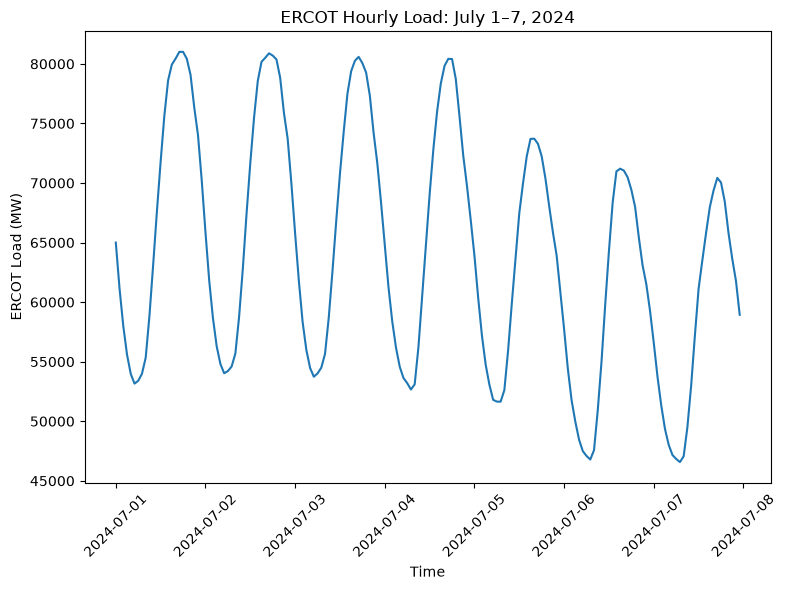

In [63]:
week =df.loc["2024-07-01":"2024-07-07"]
plt.figure(figsize=(8, 6))
plt.plot(week.index, week["ERCOT"])

plt.xlabel("Time")
plt.ylabel("ERCOT Load (MW)")
plt.title("ERCOT Hourly Load: July 1–7, 2024")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
df["hour"] = df.index.hour

hourly_average = df.groupby("hour")["ERCOT"].mean()
hourly_average

hour
0     49604.281357
1     47194.734170
2     45533.805563
3     44388.926002
4     43793.930325
5     43888.210885
6     44953.803507
7     46762.448436
8     47840.905220
9     49077.180474
10    50700.194690
11    52378.520541
12    53986.576046
13    55487.252547
14    56891.205148
15    57931.495816
16    58672.975320
17    59234.988883
18    59450.591938
19    59032.565418
20    57834.695195
21    56568.694344
22    54963.491271
23    52392.694988
Name: ERCOT, dtype: float64

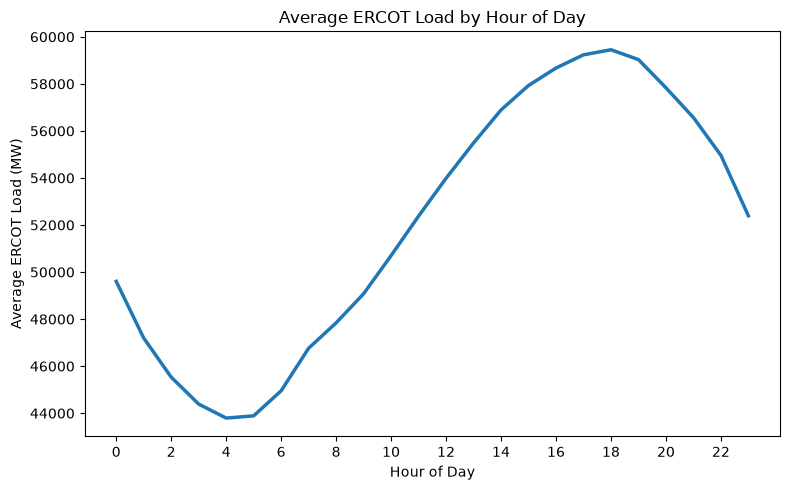

In [72]:
plt.figure(figsize=(8, 5))
plt.plot(hourly_average.index, hourly_average.values, linewidth=2.5)

plt.xlabel("Hour of Day")
plt.ylabel("Average ERCOT Load (MW)")
plt.title("Average ERCOT Load by Hour of Day")

plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

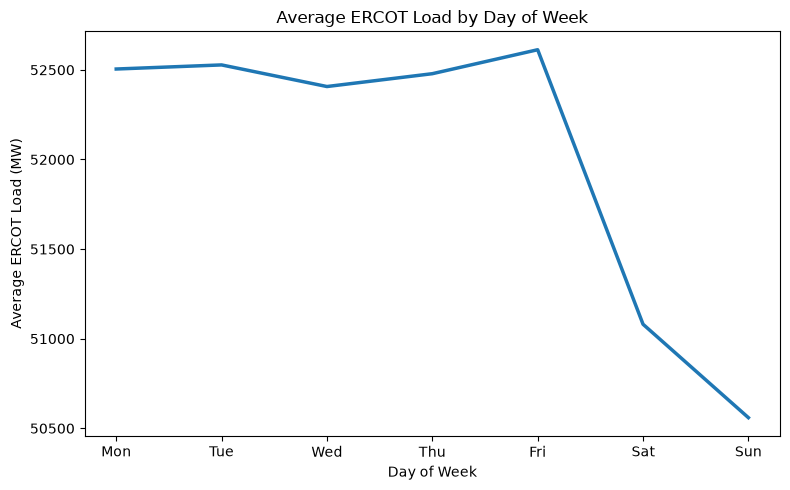

In [82]:
df["day_of_week"] = df.index.dayofweek
daily_average = df.groupby("day_of_week")["ERCOT"].mean()
daily_average

plt.figure(figsize=(8, 5))
plt.plot(daily_average.index, daily_average.values, linewidth=2.5)

plt.xlabel("Day of Week")
plt.ylabel("Average ERCOT Load (MW)")
plt.title("Average ERCOT Load by Day of Week")

plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)
plt.tight_layout()
plt.show()

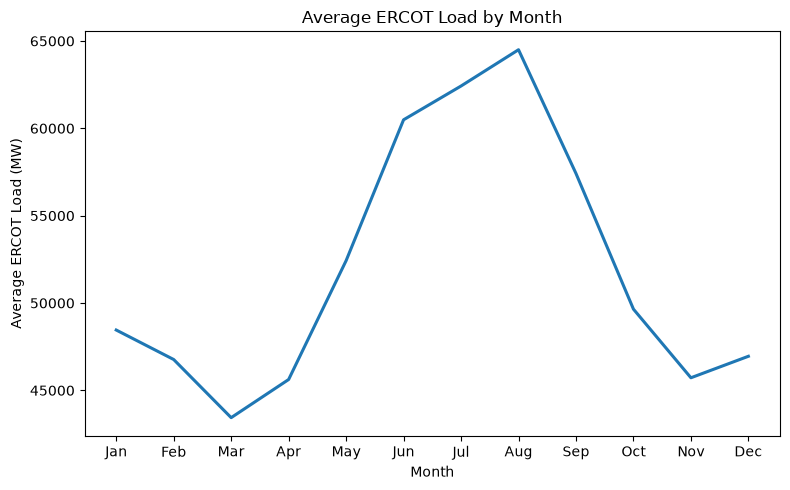

In [85]:
df["month"] = df.index.month

monthly_average = df.groupby("month")["ERCOT"].mean()
monthly_average

plt.figure(figsize=(8, 5))

plt.plot(monthly_average.index, monthly_average.values, linewidth=2.2)

plt.xlabel("Month")
plt.ylabel("Average ERCOT Load (MW)")
plt.title("Average ERCOT Load by Month")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.tight_layout()
plt.show()

In [88]:
#.shift(24) moves the series down by 24 rows, so each timestamp gets the load from 24 hours earlier.

df["load_24h_ago"] = df["ERCOT"].shift(24)
df["load_168h_ago"] = df["ERCOT"].shift(168)

In [92]:
import os

#WE NOW CREATE THE DATASET
model_df = df.dropna().copy()

os.makedirs("../data/processed", exist_ok=True)

model_df.to_csv("../data/processed/model_data.csv",index=True,index_label="timestamp") #SAVE THE PROCESSED DATA AS .csv 